## Creating a proof of concept for the Bayesian framework

To keep the proof of concept simple, I assume that a negative binomial distribution is well suited for estimating a player point distribution, that is based on the following graph;

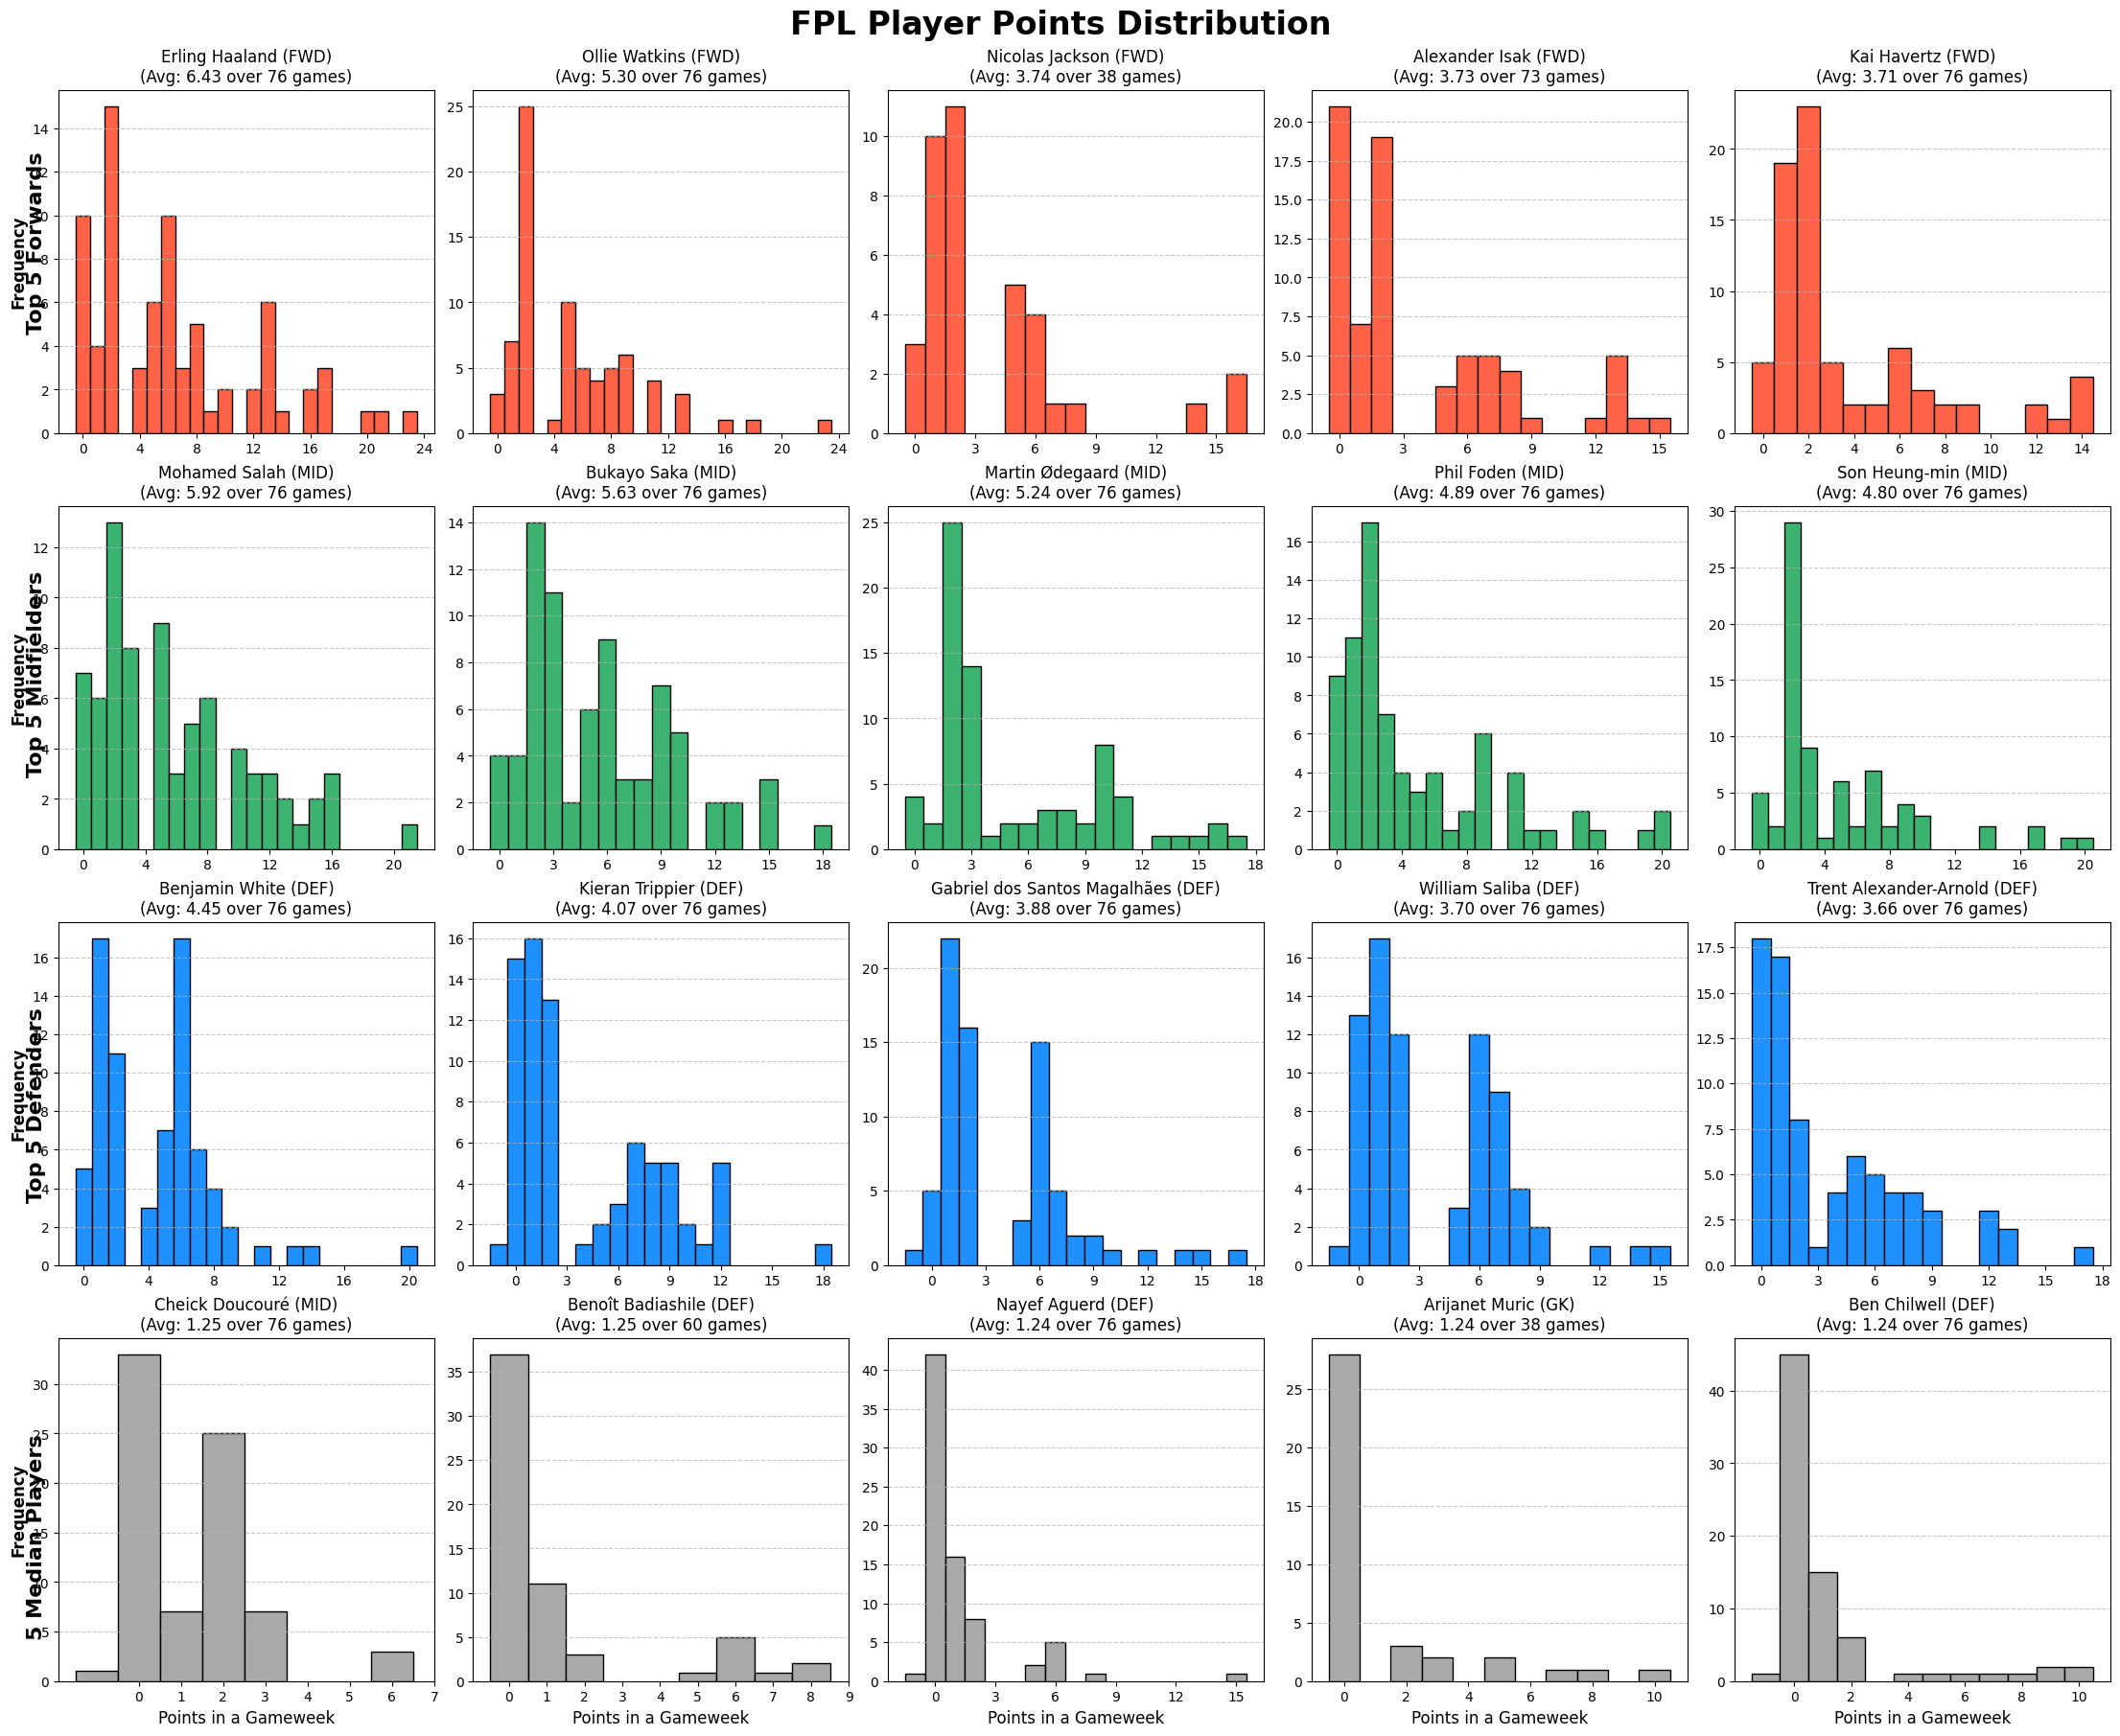

The player used for this analysis is Erling Haaland!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import nbinom
from scipy.optimize import minimize

In [2]:
with open("../data/processed/player_points_histogram.json", 'r') as f:
    raw_data = json.load(f)
    HAALAND_DATA = raw_data.get("Erling Haaland")

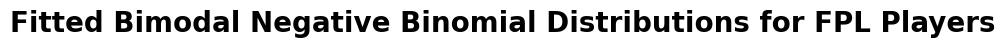

In [ ]:
def negative_bimodal_pmf(x, w, mu1, alpha1, mu2, alpha2):
    """
    Probability Mass Function (PMF) for a bimodal negative binomial distribution.
    Scipy's nbinom uses n (size/alpha) and p (prob). We convert from mu and alpha.
    """
    # PMF of the first component ("blank" scores)
    p1 = alpha1 / (alpha1 + mu1)
    pmf1 = nbinom.pmf(x, n=alpha1, p=p1)
    
    # PMF of the second component ("haul" scores)
    p2 = alpha2 / (alpha2 + mu2)
    pmf2 = nbinom.pmf(x, n=alpha2, p=p2)
    
    # Combine the two distributions with the weight
    return (1 - w) * pmf1 + w * pmf2

def neg_log_likelihood(params, data):
    """
    Objective function for the optimizer: the negative log-likelihood.
    We want to minimize this function to find the best parameters.
    """
    w, mu1, alpha1, mu2, alpha2 = params
    
    # Calculate the probability of each observed data point
    probabilities = negative_bimodal_pmf(data, w, mu1, alpha1, mu2, alpha2)
    
    # To avoid log(0) errors, add a very small constant
    probabilities[probabilities <= 0] = 1e-9
    
    # Return the negative sum of log probabilities
    return -np.sum(np.log(probabilities))

# --- Part 3: Fitting and Plotting ---

def fit_and_plot(ax, player_name, player_data, stats_df, color='skyblue'):
    """
    Fits the bimodal model to a player's data and plots it on a given axes.
    """
    points_data = player_data.get(player_name)
    if not points_data or player_name not in stats_df.index:
        ax.set_title(f"{player_name}\\n(No Data)")
        return

    # 1. Plot the original histogram
    points = np.array(list(points_data.keys()))
    counts = np.array(list(points_data.values()))
    total_games = sum(counts)
    
    ax.bar(points, counts, color=color, edgecolor='black', width=1.0, alpha=0.6, label='Observed Data')
    
    # 2. Prepare data for fitting
    # Expand the histogram into a full data array for the likelihood function
    observed_scores = np.repeat(points, counts)

    # 3. Fit the model using optimization
    # Initial guesses for the parameters [w, mu1, alpha1, mu2, alpha2]
    initial_guess = [0.3, 2.5, 1.0, 8.0, 2.0]
    
    # Bounds to ensure parameters are valid (e.g., probabilities 0-1, others > 0)
    bounds = [(0, 1), (0.1, 10), (0.1, 20), (1, 25), (0.1, 20)]

    result = minimize(
        neg_log_likelihood,
        initial_guess,
        args=(observed_scores,),
        bounds=bounds,
        method='L-BFGS-B' # A good choice for bounded optimization
    )
    
    # Extract the best-fit parameters
    w_fit, mu1_fit, alpha1_fit, mu2_fit, alpha2_fit = result.x

    # 4. Plot the fitted distribution
    x_plot = np.arange(0, max(points) + 2)
    
    # Get the overall fitted PMF and scale it to match the histogram frequency
    fitted_pmf = negative_bimodal_pmf(x_plot, w_fit, mu1_fit, alpha1_fit, mu2_fit, alpha2_fit)
    ax.plot(x_plot, fitted_pmf * total_games, color='red', linewidth=2.5, label='Fitted Bimodal Dist.')
    
    # Plot the individual components
    p1 = alpha1_fit / (alpha1_fit + mu1_fit)
    comp1_pmf = (1 - w_fit) * nbinom.pmf(x_plot, n=alpha1_fit, p=p1)
    ax.plot(x_plot, comp1_pmf * total_games, color='darkorange', linestyle='--', label=f'Blank (μ={mu1_fit:.1f})')
    
    p2 = alpha2_fit / (alpha2_fit + mu2_fit)
    comp2_pmf = w_fit * nbinom.pmf(x_plot, n=alpha2_fit, p=p2)
    ax.plot(x_plot, comp2_pmf * total_games, color='purple', linestyle='--', label=f'Haul (μ={mu2_fit:.1f})')
    
    # Final plot formatting from your notebook
    avg_score = stats_df.loc[player_name, 'average_score']
    games_played = stats_df.loc[player_name, 'count']
    position = stats_df.loc[player_name, 'position']
    ax.set_title(f"{player_name} ({position})\\n(Avg: {avg_score:.2f} over {int(games_played)} games)")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_xticks(np.arange(0, max(points) + 2, step=max(1, (max(points) // 5))))
    ax.legend(fontsize='small')


# --- Main Execution ---
#

# Select a few key players to demonstrate the fitting process
players_to_plot = {
    'Forwards': (['Erling Haaland', 'Ollie Watkins'], 'tomato'),
    'Midfielders': (['Mohamed Salah', 'Bukayo Saka'], 'mediumseagreen'),
    'Defenders': (['Kieran Trippier', 'Trent Alexander-Arnold'], 'dodgerblue'),
}

# Create a figure to display the results
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14), constrained_layout=True)
fig.suptitle('Fitted Bimodal Negative Binomial Distributions for FPL Players', fontsize=20, weight='bold')

# Flatten the axes array for easy iteration
axes = axes.flatten()
plot_idx = 0

for category, (player_list, color) in players_to_plot.items():
    for player_name in player_list:
        if plot_idx < len(axes):
            fit_and_plot(axes[plot_idx], player_name, player_histogram_dict, sorted_stats, color=color)
            axes[plot_idx].set_xlabel("Points in a Gameweek")
            axes[plot_idx].set_ylabel("Frequency")
            plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.show()